<a href="https://www.kaggle.com/code/chuyenhocielts/google-data-analytics?scriptVersionId=317772236" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## I. Introduction 
This case study is part of the Google Data Analytics Professional Certificate course on Coursera.
Instead of using R and SQL, which are the primary languages taught in the Coursera program, this case study will be conducted using Python, leveraging the Pandas and Matplotlib libraries for data analysis and visualization. 

### 1. Background information 
Cyclistic is a fictional bike-share company in Chicago. In 2016, Cyclistic launched a successful bike-share offering. Since then, the program has grown to a fleet of 5824 bicycles that are geotracked and locked into a network of 692 stations across Chicago. Although the pricing exibility helps Cyclistic aract more customers,it is believed that maximizing the number of annual members will be key to future growth. 

### 2. Purpose 
The goal of this case study is to increase the number of members by converting casual riders into annual members. By analyzing historical bike trip data, the analysis aims to identify usage patterns, behaviors, and trends between two groups, providing actionable insights to recommend marketing strategies.

## II. Data preparation and analysis 
### 1. Data preparation 
The case study uses the public Divvy bik trip history dataset, where each entry represents a single bike ride. The analysis is limited to rides recorded from January to July 2025. This is [link](https://drive.google.com/drive/folders/1PnTHxsDjJ4HdgldUxe0Rr9tnHR2FCrA2?usp=drive_link) to my dataset.

### 2. Data processing 
This stage involve cleaning and vertifying the integrity of data prior to analysis. 

In [1]:
# loading libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

Checking information of 7 files 

In [2]:
dfs = [] # use to merge all data frames 
for i in range(1, 8):
    df = pd.read_csv(f'/kaggle/input/divvy-data/2025{str(i).zfill(2)}-divvy-tripdata.csv')
    print(f'File {i}')
    print(df.info())
    print("----------------------------")
    dfs.append(df)

File 1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138689 entries, 0 to 138688
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             138689 non-null  object 
 1   rideable_type       138689 non-null  object 
 2   started_at          138689 non-null  object 
 3   ended_at            138689 non-null  object 
 4   start_station_name  115837 non-null  object 
 5   start_station_id    115837 non-null  object 
 6   end_station_name    114616 non-null  object 
 7   end_station_id      114616 non-null  object 
 8   start_lat           138689 non-null  float64
 9   start_lng           138689 non-null  float64
 10  end_lat             138628 non-null  float64
 11  end_lng             138628 non-null  float64
 12  member_casual       138689 non-null  object 
dtypes: float64(4), object(9)
memory usage: 13.8+ MB
None
----------------------------
File 2
<class 'pandas.core.frame.DataFrame'>


After running above code, we can see that all files have the same structure, so we can merge together.

In [3]:
data = pd.concat(dfs, axis = 0, ignore_index = True)

# Save file
data.to_csv('merged_data.csv', index = False)


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2904857 entries, 0 to 2904856
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 288.1+ MB


In [5]:
# check how many rows and cols after merging 
data.shape

(2904857, 13)

In [6]:
# checking for duplicate rows 
data.duplicated().sum() 

0

In [7]:
# checking duplicate rows for unique key 
data.duplicated(subset = 'ride_id').sum()

0

In [8]:
# check the valid length of ride_id
ride_id_lengths = data['ride_id'].str.len().value_counts()

print(ride_id_lengths)
print(data['ride_id'].nunique() == len(data))


ride_id
16    2904857
Name: count, dtype: int64
True


In [9]:
# checking for null values 
data.isnull().sum()

ride_id                    0
rideable_type              0
started_at                 0
ended_at                   0
start_station_name    603106
start_station_id      603106
end_station_name      628655
end_station_id        628655
start_lat                  0
start_lng                  0
end_lat                 3158
end_lng                 3158
member_casual              0
dtype: int64

Perhaps due to privacy concerns, there are many null values for start_station_name, start_station_id, end_station_name, end_station_id. And because they take up for high percentage in this dataset, so I decide to keep them to analyze. However, end_lat, end_lng make up for little percentage, so I delete them to keep data'integrity.

In [10]:
data.dropna(subset = ['end_lat', 'end_lng'], inplace = True)

Now, check the logic and convert format.

In [11]:
# converted the started_at and ended_at to datetime datatype
data['started_at'] = pd.to_datetime(data['started_at'].map(lambda timeStr : timeStr[:19]))
data['ended_at'] = pd.to_datetime(data['ended_at'].map(lambda timeStr : timeStr[:19]))
#explain why slicing 19: YYYY-MM-DD HH:MM:SS

# if start_at > end_at, it doesn't make sense
error_count = data.loc[data.started_at > data.ended_at].shape[0] 
print(error_count)

0


In [12]:
# check the validation of vehicle input 
data['rideable_type'].unique()

array(['classic_bike', 'electric_bike'], dtype=object)

In [13]:
# Check if the coordinates are valid
lat_ok = data['start_lat'].between(-90, 90).all() and data['end_lat'].between(-90, 90).all()
lng_ok = data['start_lng'].between(-180, 180).all() and data['end_lng'].between(-180, 180).all()
print(lat_ok) 
print(lng_ok)

True
True


Now, we can sure that our data is clean.

In [14]:
data = data.sort_values(by = 'ride_id')
data.to_csv('2025-divvy-tripdata-cleaned.csv', index = False)

### 3. Data analysis and visualization

In [15]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2901699 entries, 1297844 to 974550
Data columns (total 13 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             object        
 1   rideable_type       object        
 2   started_at          datetime64[ns]
 3   ended_at            datetime64[ns]
 4   start_station_name  object        
 5   start_station_id    object        
 6   end_station_name    object        
 7   end_station_id      object        
 8   start_lat           float64       
 9   start_lng           float64       
 10  end_lat             float64       
 11  end_lng             float64       
 12  member_casual       object        
dtypes: datetime64[ns](2), float64(4), object(7)
memory usage: 309.9+ MB


In [16]:
# creating necessary cols 
data['ride_length'] = data['ended_at'] - data['started_at']
def categorize_ride_trip_length(ride_length): 
    if ride_length < pd.Timedelta(minutes = 1): 
        return 'Invalid'
    elif ride_length < pd.Timedelta(minutes  = 15):
        return 'Short'
    elif ride_length < pd.Timedelta(minutes = 30):
        return 'Medium'
    elif ride_length < pd.Timedelta(minutes = 60):
        return 'Long'
    else:
        return 'Very long'
data['trip_type'] = data['ride_length'].apply(categorize_ride_trip_length)

data['month_start'] = data['started_at'].dt.month

data['day_of_week'] = data['started_at'].dt.weekday # 0 for Monday, 6 for Sunday

data['hour_of_day'] = data['started_at'].dt.hour

def categorize_hour_of_day(hour_of_day):
    if 5 <= hour_of_day <= 9:
        return 'Morning'
    elif 10 <= hour_of_day <= 15:
        return 'Midday'
    elif 16 <= hour_of_day <= 18:
        return 'Afternoon'
    elif 19 <= hour_of_day <= 22:
        return 'Evening'
    else:
        return 'Night'
data['trip_start_time'] = data.hour_of_day.map(categorize_hour_of_day)

In [17]:
has_invalid = (data['trip_type'] == 'Invalid').sum()
has_invalid

75412

In [18]:
# delete invalid trip_type 
data = data[data['trip_type'] != 'Invalid']

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2826287 entries, 1297844 to 974550
Data columns (total 19 columns):
 #   Column              Dtype          
---  ------              -----          
 0   ride_id             object         
 1   rideable_type       object         
 2   started_at          datetime64[ns] 
 3   ended_at            datetime64[ns] 
 4   start_station_name  object         
 5   start_station_id    object         
 6   end_station_name    object         
 7   end_station_id      object         
 8   start_lat           float64        
 9   start_lng           float64        
 10  end_lat             float64        
 11  end_lng             float64        
 12  member_casual       object         
 13  ride_length         timedelta64[ns]
 14  trip_type           object         
 15  month_start         int32          
 16  day_of_week         int32          
 17  hour_of_day         int32          
 18  trip_start_time     object         
dtypes: datetime64[ns](2),

In [20]:
colors = ['deepskyblue', 'crimson']
title_font = {
    'weight': 'bold',
    'size': 14
}
label_font = {
    'size': 12
}
border = {'edgecolor': 'black', 'linewidth': 1.2}

months = list(range(1, 7))

#### Analysis by member_casual and trip_type

In [21]:
# Ride aggregations: number of rides, mean, total ride time
trip_order = ['Short', 'Medium', 'Long', 'Very long']

ride_agg = data.groupby(['member_casual', 'trip_type']) \
    .agg({'ride_length': ['size', 'mean']}) \
    .reset_index()

ride_agg.columns = ['member_casual', 'trip_type', 'ride_count', 'mean_time']

ride_agg['trip_type'] = pd.Categorical(
    ride_agg['trip_type'],
    categories = trip_order,
    ordered = True
)

ride_agg = ride_agg.sort_values(by = ['member_casual', 'trip_type'])
 

print("Ride aggregations:")
print(ride_agg)

Ride aggregations:
  member_casual  trip_type  ride_count                 mean_time
2        casual      Short      596485 0 days 00:08:01.580564473
1        casual     Medium      242712 0 days 00:20:55.434585022
0        casual       Long      111749 0 days 00:41:04.208628265
3        casual  Very long       50500 0 days 02:00:15.452475247
6        member      Short     1393773 0 days 00:07:18.338166258
5        member     Medium      334465 0 days 00:20:24.271017894
4        member       Long       85605 0 days 00:38:26.739477834
7        member  Very long       10998 0 days 02:23:42.466993998


### syntax bar chart

``` python 
ax.bar(x_values, y_values, 
       width=bar_width, 
       label="label_name", 
       color="color_name_or_code", 
       edgecolor="edge_color", 
       linewidth=number, 
       alpha=transparency_value)


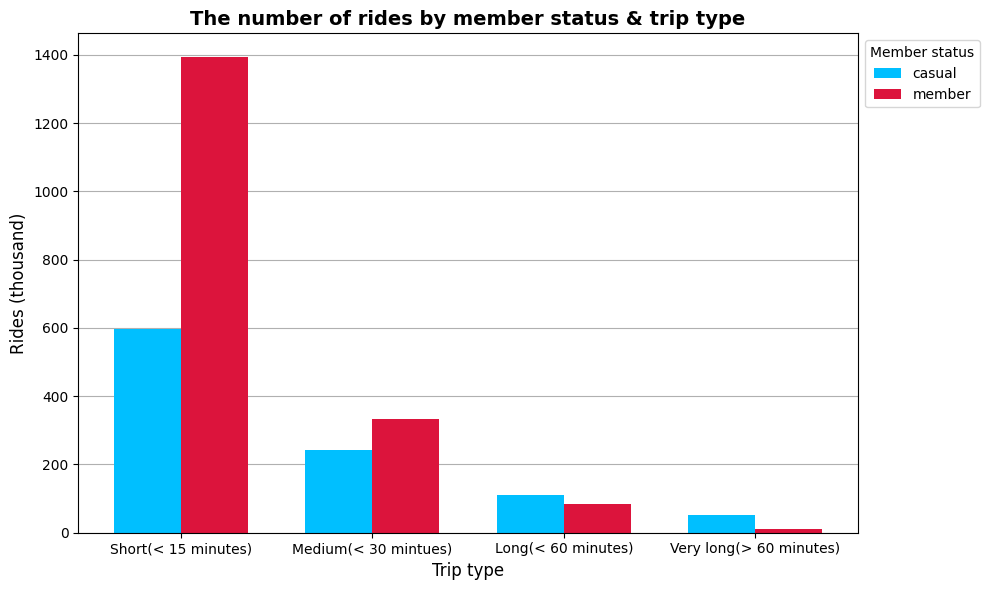

In [22]:
trip_names = ['Short(< 15 minutes)', 'Medium(< 30 mintues)', 'Long(< 60 minutes)', 'Very long(> 60 minutes)']
trip_types = trip_order
members = ["casual", "member"]  
x = np.arange(len(trip_types))
width = 0.35

ride_plot = ride_agg.copy()
ride_plot['ride_count'] /= 1000

fig, ax7 = plt.subplots(figsize=(10, 6))

for i, member in enumerate(members):
    member_data = ride_plot[ride_plot['member_casual'] == member]
    ax7.bar(
        x + i * width,
        member_data['ride_count'],
        width,
        color=colors[i],
        label=member
    )

ax7.set_xlabel("Trip type", fontdict=label_font)
ax7.set_ylabel("Rides (thousand)", fontdict=label_font)
ax7.set_title("The number of rides by member status & trip type", fontdict=title_font)
ax7.set_xticks(x + width / 2)
ax7.set_xticklabels(trip_names)
ax7.legend(title="Member status", loc="upper left", bbox_to_anchor=(1, 1))
ax7.set_axisbelow(True)
ax7.grid(axis='y')

plt.tight_layout()
plt.show()


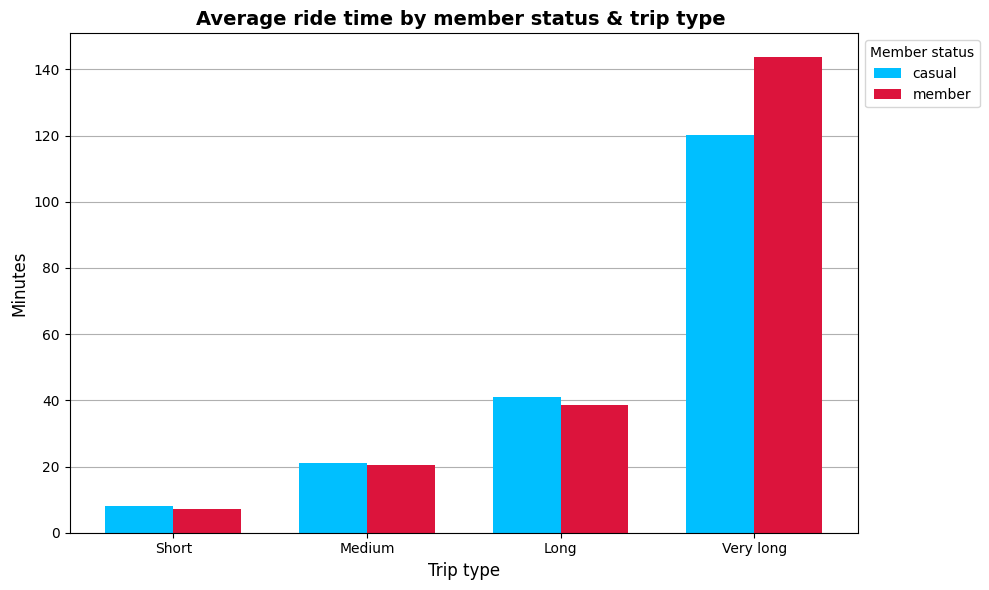

In [23]:
trip_types = trip_order
members = ride_agg['member_casual'].unique()
ride_agg['minutes_mean'] = ride_agg['mean_time'].dt.total_seconds() / 60


x = np.arange(len(trip_types)) # numbers of cols showing in bar chart
width = 0.35 # the width of each col

fig, ax8 = plt.subplots(figsize=(10, 6))

for i, member in enumerate(members):
    member_data = ride_agg[ride_agg['member_casual'] == member]
    ax8.bar(
        x + i * width, # location of each col 
        member_data['minutes_mean'], # height
        width, 
        color=colors[i],
        label=member
    )


ax8.set_xlabel("Trip type", fontdict=label_font)
ax8.set_ylabel("Minutes", fontdict=label_font)
ax8.set_title("Average ride time by member status & trip type ", fontdict=title_font)
ax8.set_xticks(x + width / 2) # labels centered between groups of bars
ax8.set_xticklabels(trip_types)
ax8.legend(title="Member status", loc="upper left", bbox_to_anchor=(1, 1))
ax8.set_axisbelow(True)
ax8.grid(axis='y')

plt.tight_layout()


In [24]:
total_time_and_ride = data.groupby('member_casual').agg({'ride_length': ['size', 'sum']}).reset_index()
total_time_and_ride.columns = ['member_casual', 'ride_count', 'total_time']
total_time_and_ride

,member_casual,ride_count,total_time
0,casual,1001446,14255 days 23:50:22
1,member,1824841,15193 days 11:53:52


### Syntax pie chart


```python
plt.pie(
x,                # Data (list, numpy array, Series) - values that form the slices
labels=None,      # Labels for each slice
colors=None,      # List of colors for each slice
autopct=None,     # Format string to display percentage, e.g., '%1.1f%%'
startangle=None,  # Starting angle for the pie (default 0 degrees, 90 for horizontal)
shadow=False,     # Whether to draw a shadow
explode=None,     # List of offsets to "explode" slices outward (e.g., [0, 0.1, 0])
radius=1.0        # Radius of the pie chart

)
```


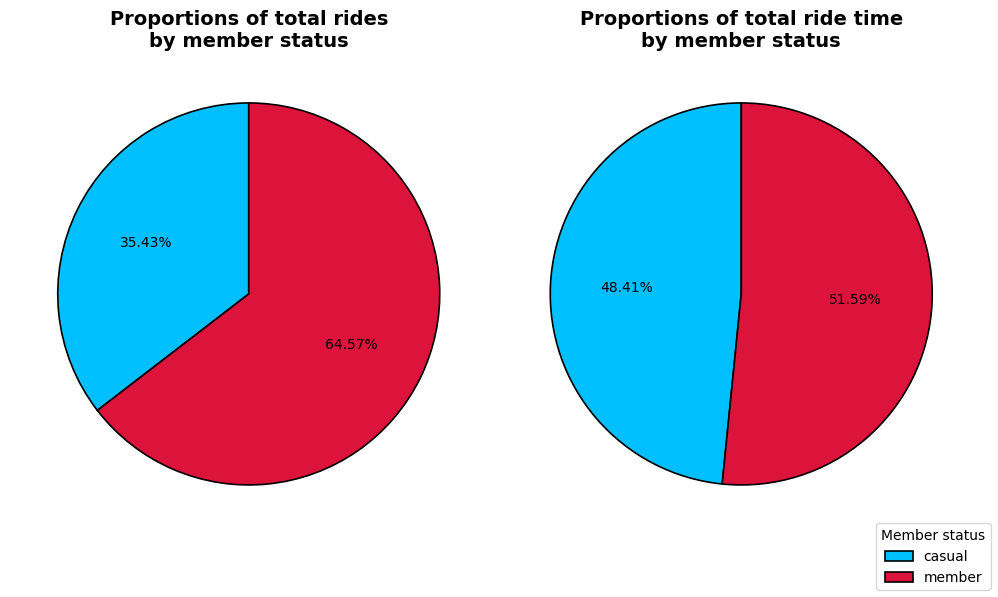

In [25]:
fig2, ax9 = plt.subplots(1, 2, figsize = (10, 6))
ax9[0].pie(total_time_and_ride['ride_count'], colors = colors, startangle = 90, autopct='%1.2f%%', wedgeprops = border)
ax9[0].set_title("Proportions of total rides\nby member status", fontdict = title_font)

ax9[1].pie(total_time_and_ride['total_time'], colors = colors, startangle = 90, autopct='%1.2f%%', wedgeprops = border)
ax9[1].set_title("Proportions of total ride time\nby member status", fontdict = title_font)

fig2.legend(total_time_and_ride['member_casual'], title="Member status", loc="lower right")

fig2.tight_layout()  

plt.show()

### Analysis
- Overall, the number of rides taken by members was significantly higher than that taken by casuals, with nearly two thirds of total rides attributed to members. Whereas, the total ride time between 2 groups was approximately equal.

- Regarding the number of rides taken by 2 groups, the largest differences between 2 groups lies in the short time trips, where the members' numbers more than doubled those of casual riders. Followed by the medium-duration trips, members took about 50000 more rides than the another. However, there were more long and very long time rides taken by casuals compared to members. 

- Turning to the average ride time, casuals had a tendency to ride slightly longer than members s across all trip types except for very long trips. As for very long trip, members rode much more time than casuals, about above 20 minutes.

### Conclusion 
- Beacause the casual wanted to experience the service, they took more long rides than members who paid more money to have more benefits. But they tended to ride bikes long or very long, which made them easily feel tired and hard to maintain consistency. Therefore, their trips' number was lower greatly than that of members. To encourage casual riders to become members, we could provide guidelines on optimal ride durations for beginners.
- Members who take very long-duration trips may have specific goals, such as training for competitions or pursuing personal fitness challenges. Further research could clarify their motivations. They also ride more trips than casuals because they spent suitable time per trip and have consistency.

#### Analysis by member_casual and month

In [26]:
# Number of rides, average time of one ride, total time of all rides, categorized by member status and month
print("Ride aggregations by month:")
ride_agg_month = data.groupby(['member_casual', 'month_start']).agg({'ride_length': ['size', 'mean', 'sum']}).reset_index()
ride_agg_month.columns = ['member_casual', 'month', 'ride_count', 'mean_time', 'total_time']

print(ride_agg_month)

Ride aggregations by month:
   member_casual  month  ride_count                 mean_time  \
0         casual      1       23408 0 days 00:12:09.836936090   
1         casual      2       27005 0 days 00:12:26.152082947   
2         casual      3       82880 0 days 00:18:01.478088803   
3         casual      4      105283 0 days 00:18:50.297711881   
4         casual      5      175680 0 days 00:20:57.382371357   
5         casual      6      278730 0 days 00:21:58.998694076   
6         casual      7      308423 0 days 00:21:27.584372760   
7         casual     12          37 0 days 01:24:36.972972972   
8         member      1      112346 0 days 00:10:02.701377886   
9         member      2      122111 0 days 00:09:58.881632285   
10        member      3      208473 0 days 00:11:09.737203378   
11        member      4      257933 0 days 00:11:17.113917180   
12        member      5      314019 0 days 00:11:54.603810597   
13        member      6      379540 0 days 00:12:50.793803024 

In [27]:
# I noticed that there were wrong data regrading to months. Since the number of errors is small, I just simply delete them.
ride_agg_month = ride_agg_month[ride_agg_month['month'].between(1, 7)]

### syntax line chart

```python
ax.plot(x_values, y_values, 
        label="label_name", 
        color="color_name_or_code", 
        marker="marker_style", 
        linestyle="line_style", 
        linewidth=number, 
        alpha=transparency_value)


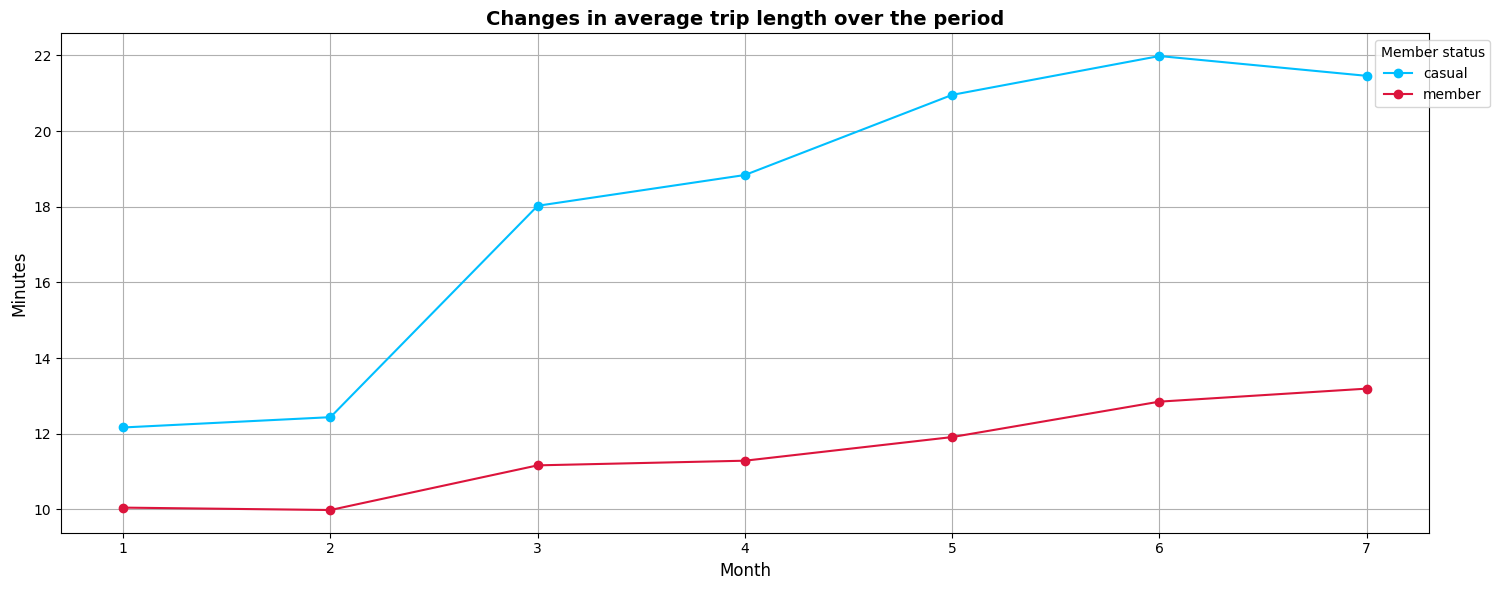

In [28]:
# Convert time to minutes
temp_ride_agg_month = ride_agg_month.copy()
temp_ride_agg_month['minutes_mean'] = ride_agg_month['mean_time'].dt.total_seconds() / 60

# Get list of months (sorted)
months = ride_agg_month['month'].sort_values().unique()

# Extract average ride length for each member type
casual_mean = temp_ride_agg_month.loc[temp_ride_agg_month['member_casual'] == 'casual', 'minutes_mean'].values
member_mean = temp_ride_agg_month.loc[temp_ride_agg_month['member_casual'] == 'member', 'minutes_mean'].values

# Create line plot for average ride length
fig3, ax10 = plt.subplots(1, 1, figsize=(15, 6))
ax10.plot(months, casual_mean, color=colors[0], marker='o', label='casual')
ax10.plot(months, member_mean, color=colors[1], marker='o', label='member')

ax10.set_xlabel("Month", fontdict=label_font)
ax10.set_ylabel("Minutes", fontdict=label_font)
ax10.set_title("Changes in average trip length over the period", fontdict=title_font)

ax10.legend(title="Member status", loc="upper right", bbox_to_anchor = (1.05, 1))
ax10.grid(True)

fig3.tight_layout()



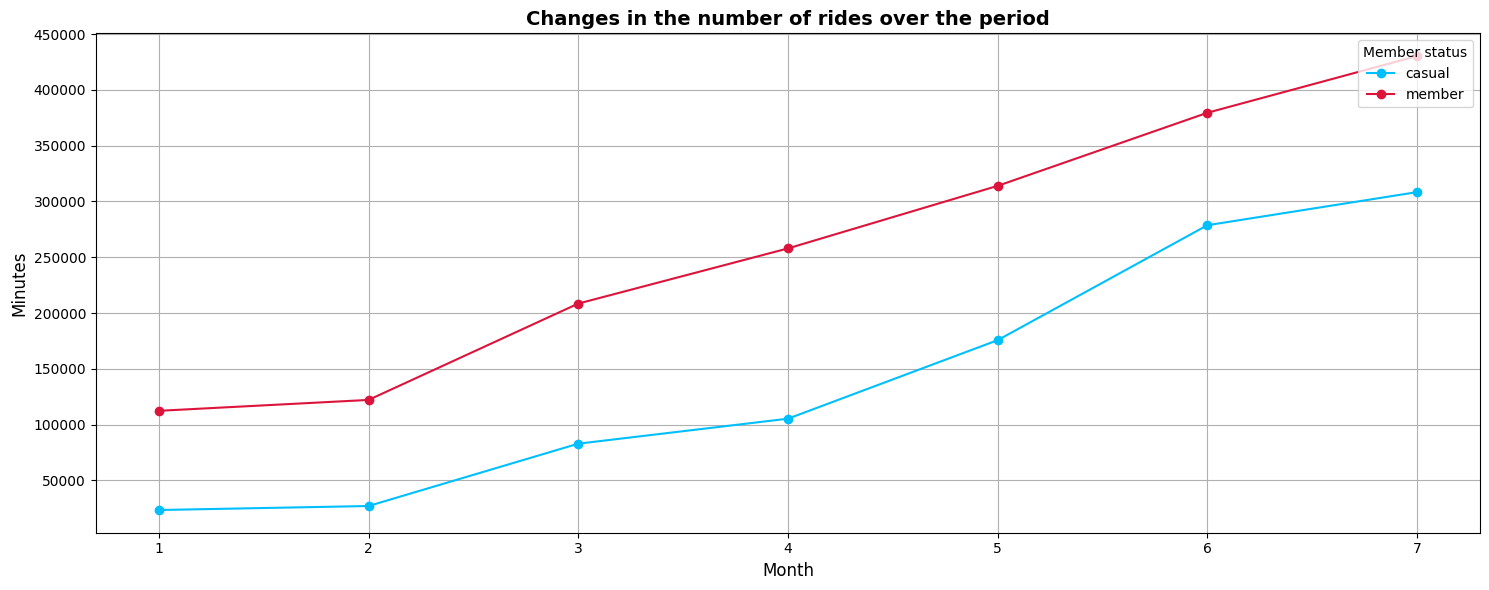

In [29]:
# Get list of months (sorted)
months = ride_agg_month['month'].sort_values().unique()

# Extract average ride length for each member type
casual_total = temp_ride_agg_month.loc[temp_ride_agg_month['member_casual'] == 'casual', 'ride_count'].values
member_total = temp_ride_agg_month.loc[temp_ride_agg_month['member_casual'] == 'member', 'ride_count'].values

# Create line plot for average ride length
fig3, ax11 = plt.subplots(1, 1, figsize=(15, 6))
ax11.plot(months, casual_total, color=colors[0], marker='o', label='casual')
ax11.plot(months, member_total, color=colors[1], marker='o', label='member')

ax11.set_xlabel("Month", fontdict=label_font)
ax11.set_ylabel("Minutes", fontdict=label_font)
ax11.set_title("Changes in the number of rides over the period", fontdict=title_font)

ax11.legend(title="Member status", loc="upper right", bbox_to_anchor=(1, 1))
ax11.grid(True)

fig3.tight_layout()

### Analysis 
- Overall, both the number of rides and the total ride time for each ride witnessed a sharp increase over the given period.
- Regarding the number of rides, both 2 groups increased significantly, reaching a peak at July. Members consistently had a higher number of rides than casual riders throughout the period, starting at around 100,000 rides in January and climbing to approximately 400,000 in July. Casual riders started lower at about 50,000 rides in January, rising to around 300,000 in July. The growth was relatively stable for both in the early months (January to March), with a more pronounced surge from April onward, though casual riders' growth accelerated faster in the later months, narrowing the gap.
- As for average trip length, casual riders had a surge from January to March (rising from about 12 minutes to 18 minutes by April), peaking at around 22 minutes in June before a slight decline to 21 minutes in July. Members' average trip length grew steadily from approximately 10 minutes in January to 13 minutes in July, without any sharp fluctuations. Throughout the period, casual riders consistently spent more time per ride compared to members.

### Conclusion 
To convert more casuals to members, strategies like seasonal promotions during peak growth months (e.g., April-July) or tailored ride duration recommendations could be effective. Further data on external factors (e.g., weather or events) would enhance understanding of these trends.

#### Analysis by member_casual and day_of_week

In [30]:
# ----- Time of day order -----
hours_order_map = {
    'Morning': 1,
    'Midday': 2,
    'Afternoon': 3,
    'Evening': 4,
    'Night': 5
}
# Total number of rides classified by time of day and member status
data['hours_order'] = data['trip_start_time'].map(hours_order_map)

hour_of_day_start = (
    data.groupby(['member_casual', 'trip_start_time', 'hours_order'])
    .size()
    .reset_index(name='ride_count')
    .sort_values(by=['member_casual', 'hours_order'])
)
print("Rides by time of day:")
print(hour_of_day_start)
print()

# Total number of rides classified by weekday and member status
day_of_week_start = data.groupby(['member_casual', 'day_of_week']).size().reset_index(name = 'ride_count').sort_values(by = ['member_casual', 'day_of_week'])
print("Rides by weekday:")
print(day_of_week_start)

Rides by time of day:
  member_casual trip_start_time  hours_order  ride_count
3        casual         Morning            1      112053
2        casual          Midday            2      365481
0        casual       Afternoon            3      272706
1        casual         Evening            4      183936
4        casual           Night            5       67270
8        member         Morning            1      391200
7        member          Midday            2      565208
5        member       Afternoon            3      523187
6        member         Evening            4      280432
9        member           Night            5       64814

Rides by weekday:
   member_casual  day_of_week  ride_count
0         casual            0      117715
1         casual            1      122136
2         casual            2      111070
3         casual            3      134555
4         casual            4      158480
5         casual            5      202203
6         casual            6      155

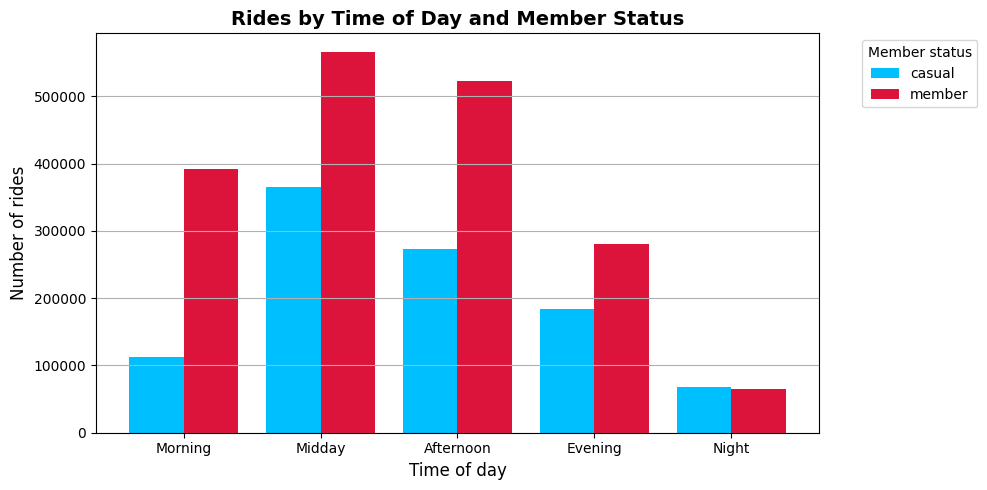

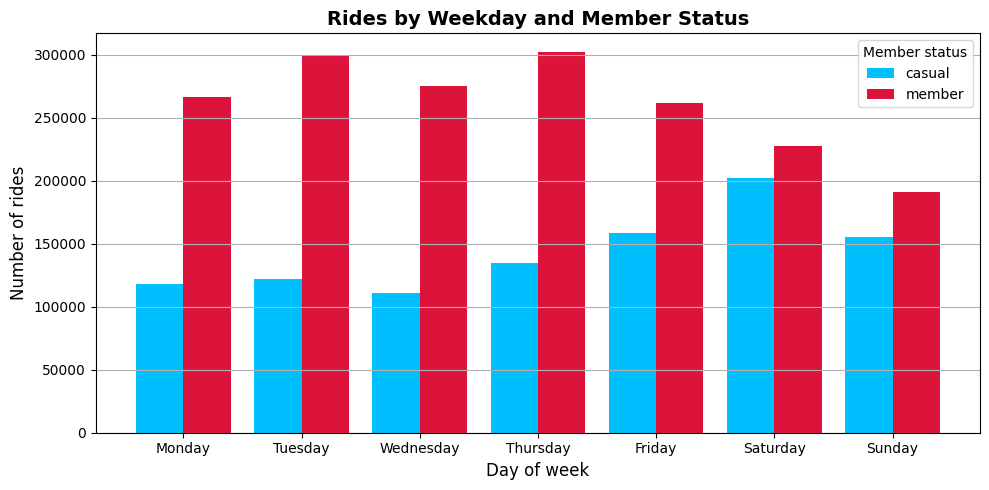

In [31]:
# ----- Grouped bar chart: Rides by time of day -----
fig1, ax11 = plt.subplots(figsize=(10, 5))
members = ['casual', 'member']

x = np.arange(len(hour_of_day_start['trip_start_time'].unique()))  # position of groups
bar_width = 0.4

for i, status in enumerate(members):
    subset = hour_of_day_start[hour_of_day_start['member_casual'] == status]
    ax11.bar(
        x + i * bar_width,  
        subset['ride_count'],
        width=bar_width,
        label=status,
        color=colors[i]
    )
ax11.set_xticks(x + bar_width / 2)
ax11.set_xticklabels(hour_of_day_start['trip_start_time'].unique())
ax11.set_xlabel("Time of day", fontdict=label_font)
ax11.set_ylabel("Number of rides", fontdict=label_font)
ax11.set_title("Rides by Time of Day and Member Status", fontdict=title_font)
ax11.legend(title="Member status", bbox_to_anchor=(1.05, 1), loc="upper left")
ax11.grid(axis='y')

plt.tight_layout()
plt.show()

# ----- Grouped bar chart: Rides by weekday -----

week_of_day_map = {
    '0': 'Monday',
    '1': 'Tuesday',
    '2': 'Wednesday',  
    '3': 'Thursday',
    '4': 'Friday',
    '5': 'Saturday',
    '6': 'Sunday'
}

day_of_week_start['Weekday_to_str'] = day_of_week_start['day_of_week'].astype(str).map(week_of_day_map)

order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_of_week_start['Weekday_to_str'] = pd.Categorical(day_of_week_start['Weekday_to_str'], categories=order, ordered=True)

fig2, ax12 = plt.subplots(figsize=(10, 5))
x = np.arange(len(order))
bar_width = 0.4

for i, status in enumerate(members):
    subset = day_of_week_start[day_of_week_start['member_casual'] == status].sort_values('Weekday_to_str')
    ax12.bar(
        x + i * bar_width,
        subset['ride_count'],
        width=bar_width,
        label=status,
        color=colors[i]
    )

ax12.set_xticks(x + bar_width / 2)
ax12.set_xticklabels(order)

ax12.set_xlabel("Day of week", fontdict=label_font)
ax12.set_ylabel("Number of rides", fontdict=label_font)
ax12.set_title("Rides by Weekday and Member Status", fontdict=title_font)
ax12.legend(title="Member status", loc="upper right")
ax12.grid(axis='y')

plt.tight_layout()
plt.show()



In [32]:
# Different bike usage classified by member status
bike_type = data.groupby(['member_casual', 'rideable_type']).size().reset_index(name = 'ride_count')
print("Different bikes usage of member and casual:")
print(bike_type)

Different bikes usage of member and casual:
  member_casual  rideable_type  ride_count
0        casual   classic_bike      369590
1        casual  electric_bike      631856
2        member   classic_bike      684733
3        member  electric_bike     1140108


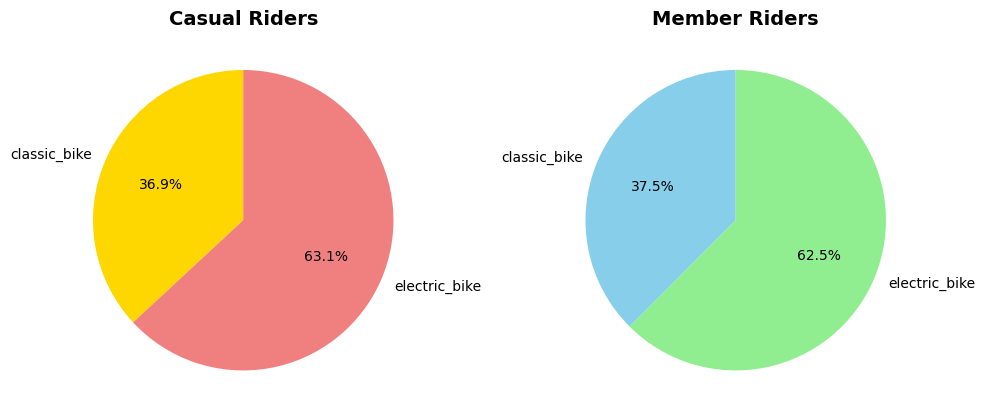

In [33]:
casual_data = bike_type[bike_type['member_casual'] == 'casual']
member_data = bike_type[bike_type['member_casual'] == 'member']

fig, ax13 = plt.subplots(1, 2, figsize=(10, 5))

ax13[0].pie(
    casual_data['ride_count'],
    labels=casual_data['rideable_type'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['gold', 'lightcoral']
)
ax13[0].set_title('Casual Riders', fontdict=title_font)

ax13[1].pie(
    member_data['ride_count'],
    labels=member_data['rideable_type'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['skyblue', 'lightgreen']
)
ax13[1].set_title('Member Riders', fontdict=title_font)

plt.tight_layout()
plt.show()


### Analysis 
- Overall: Members dominate ride volumes during weekdays and peak hours (commuting focus), while casual riders show higher relative usage on weekends and midday/afternoon (leisure-oriented).
- Rides by time of day: Peaks in midday for both (members ~550,000, casual ~370,000). Members lead in almost the stage of day, except for night; figure for both groups decreased to the night.
- Rides by weekday: Members peak midweek (Tuesday/Thursday ~300,000); casual steady but lower weekdays (~190,000–230,000). Casuals surge weekend and nearly matching Sunday (~200,000).
- Both casual and member riders preferred riding electric bikes to classic bikes.

### Conclusion 
To encourage casual riders to become members, focus on leveraging their leisure-oriented usage patterns. Offer weekend promotions, such as discounted rates or bonus rides, to attract their higher weekend activity.

## III. Answering key question and recommendations
### 1. Answering 
#### a. How do annual members and casual riders use Cyclistic bikes differently?
Annual members primarily use Cyclistic bikes for commuting to work on a daily basis. Casual riders, conversely, favor recreational use, with increased activity weekends, indicating leisure-oriented trips. 

#### b. Why would casual riders buy Cyclistic annual memberships?
Casual riders might be motivated to buy memberships if offered weekend promotions to capitalize on their peak usage, or incentives for shorter, frequent rides with clear duration guidelines to ease into regular use. Enhanced app features like personalized recommendations could also appeal to their exploratory habits, making membership cost-effective over time.

#### c. How can Cyclistic use digital media to influence casual riders to become members?
- The company could leverage digital media with targeted weekend ads on social platforms, showcasing membership benefits like weekend discount.
- They could launch some community campaigns to encourage participation, especially on weekends. Sharing engaging content on the Internet.
- - Creating more appealing marketing content and storytelling